# EconAgent — Análisis de la corrida (100 agentes, 54 meses)

Adaptado de `analysis_100agents_48months.ipynb` — misma corrida de control (N=100), extendida 6 meses más (48→54) para ver si la recuperación observada hacia el mes 48 (desempleo bajando, inflación volviendo a terreno positivo) se sostiene.

**Corrida completa (54/54 meses)** — carga el `dense_log.pkl` final.

In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (12, 4)

## 1. Cargar resultados

In [2]:
RUN_NAME = 'gpt-3-noperception-reflection-1-100agents-54months'
run_path = Path('data') / RUN_NAME

final_log_path = run_path / 'dense_log.pkl'
if final_log_path.exists():
    log_path = final_log_path
else:
    checkpoints = sorted(
        run_path.glob('dense_log_*.pkl'),
        key=lambda p: int(p.stem.split('_')[-1]),
    )
    if not checkpoints:
        raise FileNotFoundError(f'No se encontró ningún dense_log en {run_path}')
    log_path = checkpoints[-1]

with open(log_path, 'rb') as f:
    log = pkl.load(f)

print(f'Corrida: {RUN_NAME}')
print(f'Log cargado: {log_path.name}' + ('  (checkpoint parcial)' if log_path != final_log_path else '  (corrida completa)'))
print('\nClaves disponibles en dense_log:')
print(list(log.keys()))

Corrida: gpt-3-noperception-reflection-1-100agents-54months
Log cargado: dense_log.pkl  (corrida completa)

Claves disponibles en dense_log:
['world', 'states', 'actions', 'rewards', 'PeriodicTax']


## 2. Extraer series de tiempo

In [3]:
# En el último step, _finalize_logs agrega UNA entrada extra a log['world']/log['states']
# (con el dato anual del año 4 incluido) que no tiene contraparte en log['actions'].
# world_df se arma con la lista completa (para no perder ese último punto anual);
# las series por agente se alinean a T = len(actions) para poder combinarlas entre sí.
T = len(log['actions']) if log.get('actions') else len(log['states'])
n_agents = len([k for k in log['states'][0].keys() if k != 'p'])
print(f'Pasos (acciones): {T}   Entradas de world: {len(log["world"])}   Agentes: {n_agents}')

# --- Macroeconómicos (world), sin truncar ---
world_df = pd.DataFrame(log['world'])
world_df.index.name = 'step'

# --- Estados de agentes, alineados a T ---
wealth    = np.array([[log['states'][t][str(i)]['inventory']['Coin']  for i in range(n_agents)] for t in range(T)])
income    = np.array([[log['states'][t][str(i)].get('income', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T)])
skill     = np.array([[log['states'][t][str(i)]['skill']               for i in range(n_agents)] for t in range(T)])

print('world_df columnas:', list(world_df.columns))

Pasos (acciones): 54   Entradas de world: 55   Agentes: 100
world_df columnas: ['Price', '#Products', 'Interest Rate', 'Unemployment Rate', 'Real GDP', 'Nominal GDP', 'Price Inflation', 'Unemployment Rate Growth', 'Wage Inflation', 'Nominal GDP Growth', 'Real GDP Growth']


## 3. Indicadores macroeconómicos

Con `period: 12` en `config.yaml`, la tasa de desempleo/PIB/inflación son métricas **anuales** — con 48 meses corridos hay hasta 4 puntos anuales disponibles.

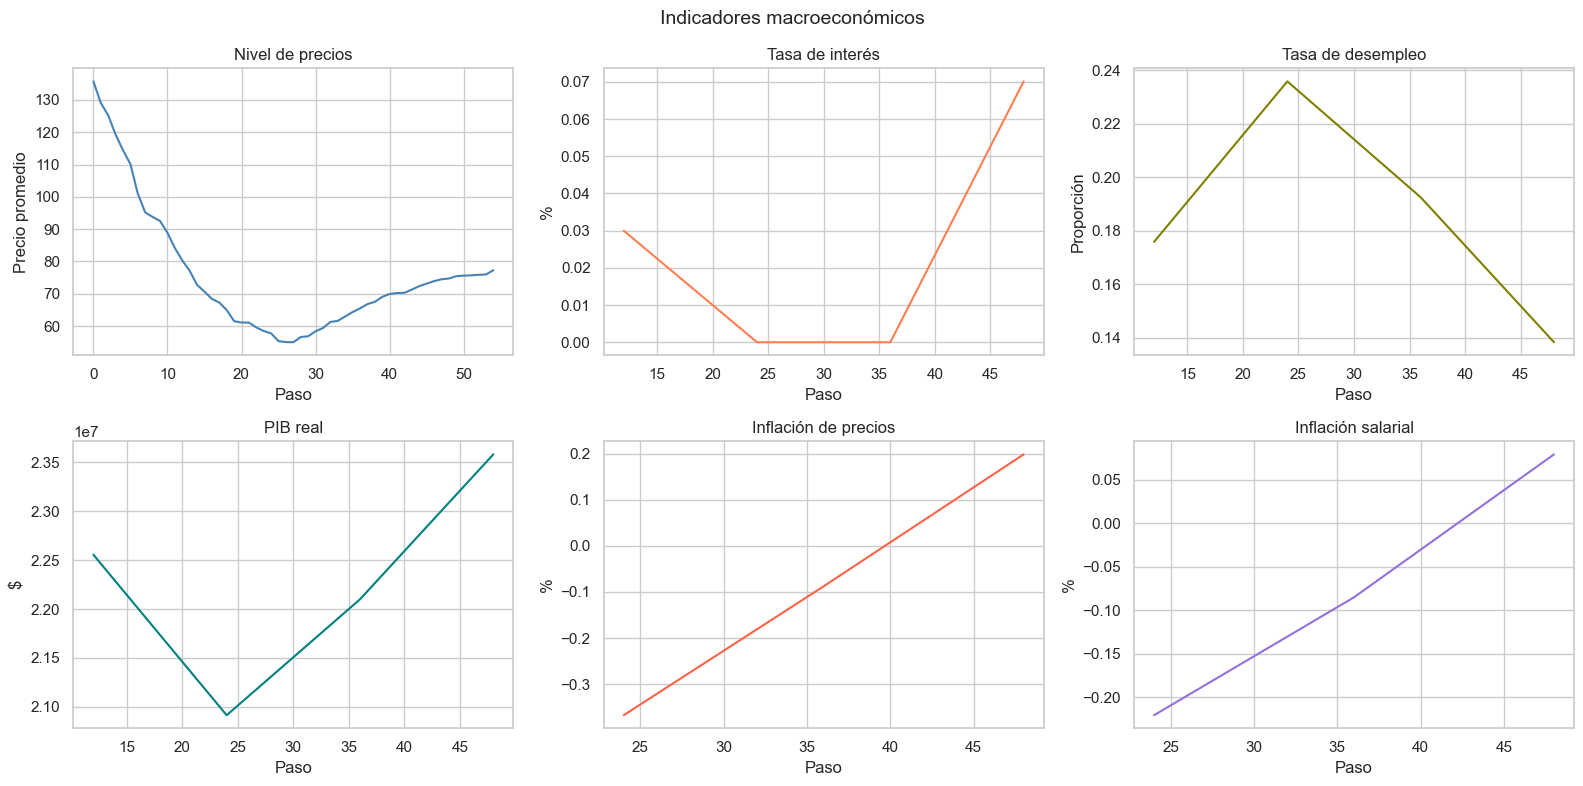

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Indicadores macroeconómicos', fontsize=14)
steps = range(T)

def plot_series(ax, series, title, ylabel, color='steelblue'):
    clean = series.dropna()
    ax.plot(clean.index, clean.values, color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Paso')

plot_series(axes[0,0], world_df['Price'],           'Nivel de precios',      'Precio promedio')
plot_series(axes[0,1], world_df.get('Interest Rate', pd.Series(dtype=float)), 'Tasa de interés', '%', color='coral')
plot_series(axes[0,2], world_df.get('Unemployment Rate', pd.Series(dtype=float)), 'Tasa de desempleo', 'Proporción', color='olive')
plot_series(axes[1,0], world_df.get('Real GDP', pd.Series(dtype=float)),       'PIB real',      '$', color='teal')
plot_series(axes[1,1], world_df.get('Price Inflation', pd.Series(dtype=float)), 'Inflación de precios', '%', color='tomato')
plot_series(axes[1,2], world_df.get('Wage Inflation', pd.Series(dtype=float)),  'Inflación salarial',  '%', color='mediumpurple')

plt.tight_layout()
plt.show()

## 4. Distribución de riqueza

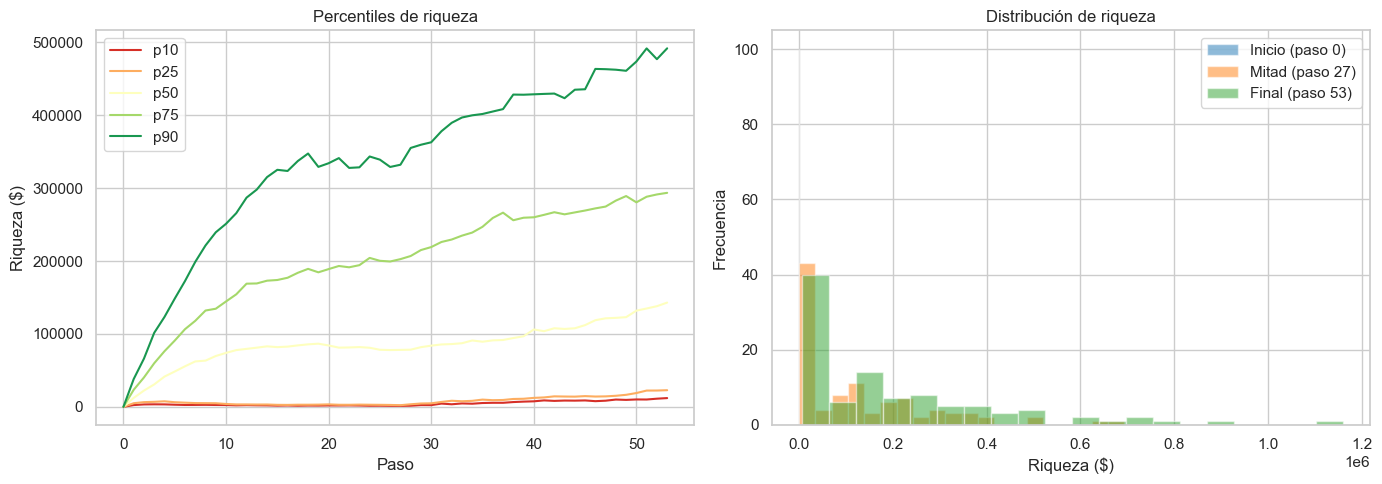

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Percentiles de riqueza a lo largo del tiempo
ax = axes[0]
quantiles = [10, 25, 50, 75, 90]
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(quantiles)))
for q, c in zip(quantiles, colors):
    ax.plot(np.percentile(wealth, q, axis=1), label=f'p{q}', color=c)
ax.set_title('Percentiles de riqueza')
ax.set_xlabel('Paso')
ax.set_ylabel('Riqueza ($)')
ax.legend()

# Distribución al inicio, mitad y final
ax = axes[1]
checkpoints = [0, T//2, T-1]
labels = ['Inicio', 'Mitad', 'Final']
for cp, label in zip(checkpoints, labels):
    ax.hist(wealth[cp], bins=20, alpha=0.5, label=f'{label} (paso {cp})')
ax.set_title('Distribución de riqueza')
ax.set_xlabel('Riqueza ($)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Coeficiente de Gini

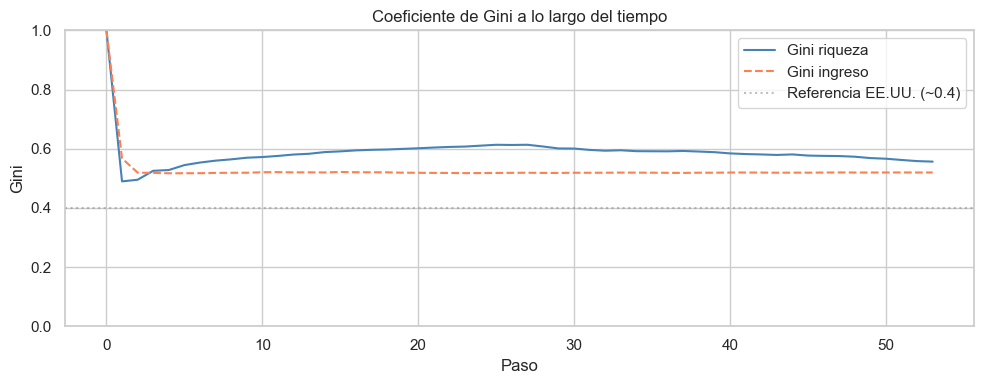

Gini riqueza  — inicio: 1.000  |  final: 0.556
Gini ingreso  — inicio: 1.000  |  final: 0.520


In [6]:
def gini(x):
    x = np.sort(np.abs(x))
    n = len(x)
    return 1 - (2 / (n + 1)) * np.sum(np.cumsum(x) / (np.sum(x) + 1e-10))

gini_wealth = [gini(wealth[t]) for t in range(T)]
gini_income = [gini(income[t]) for t in range(T)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gini_wealth, label='Gini riqueza', color='steelblue')
ax.plot(gini_income, label='Gini ingreso', color='coral', linestyle='--')
ax.set_ylim(0, 1)
ax.set_title('Coeficiente de Gini a lo largo del tiempo')
ax.set_xlabel('Paso')
ax.set_ylabel('Gini')
ax.axhline(0.4, color='gray', linestyle=':', alpha=0.5, label='Referencia EE.UU. (~0.4)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Gini riqueza  — inicio: {gini_wealth[0]:.3f}  |  final: {gini_wealth[-1]:.3f}')
print(f'Gini ingreso  — inicio: {gini_income[0]:.3f}  |  final: {gini_income[-1]:.3f}')

## 6. Curva de Lorenz (inicio vs final del tramo corrido)

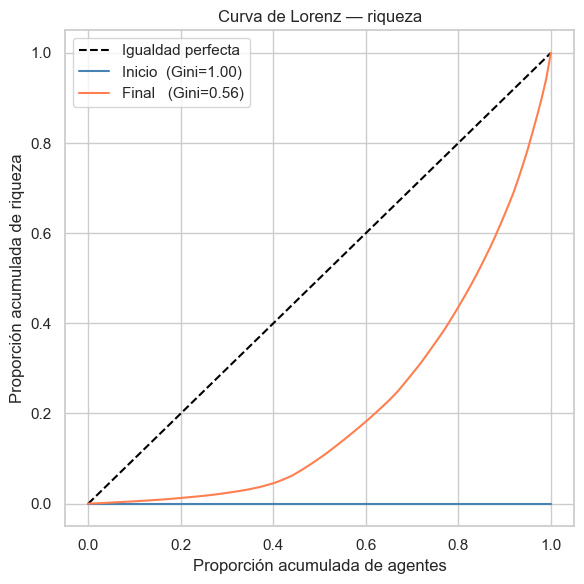

In [7]:
def lorenz(x):
    x = np.sort(np.abs(x))
    cum = np.cumsum(x) / (np.sum(x) + 1e-10)
    return np.concatenate([[0], cum])

fig, ax = plt.subplots(figsize=(6, 6))
pop = np.linspace(0, 1, n_agents + 1)

ax.plot([0, 1], [0, 1], 'k--', label='Igualdad perfecta')
ax.plot(pop, lorenz(wealth[0]),   label=f'Inicio  (Gini={gini_wealth[0]:.2f})',  color='steelblue')
ax.plot(pop, lorenz(wealth[-1]),  label=f'Final   (Gini={gini_wealth[-1]:.2f})', color='coral')

ax.set_title('Curva de Lorenz — riqueza')
ax.set_xlabel('Proporción acumulada de agentes')
ax.set_ylabel('Proporción acumulada de riqueza')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Actividad laboral y consumo

El log agregado por componente (`SimpleLabor-*`) todavía no existe (corrida parcial), pero `log['actions']` sí está disponible en cada checkpoint y trae la decisión real decodificada por agente y mes (`{'SimpleLabor': 1, 'SimpleConsumption': N}` si trabajó; sin la clave `SimpleLabor` si no trabajó). Es la fuente correcta — usar `income > 0` como proxy da resultados engañosos acá (llega a 100% de empleo casi todos los meses porque el ingreso registrado no se alinea 1 a 1 con la decisión de ese mismo mes).

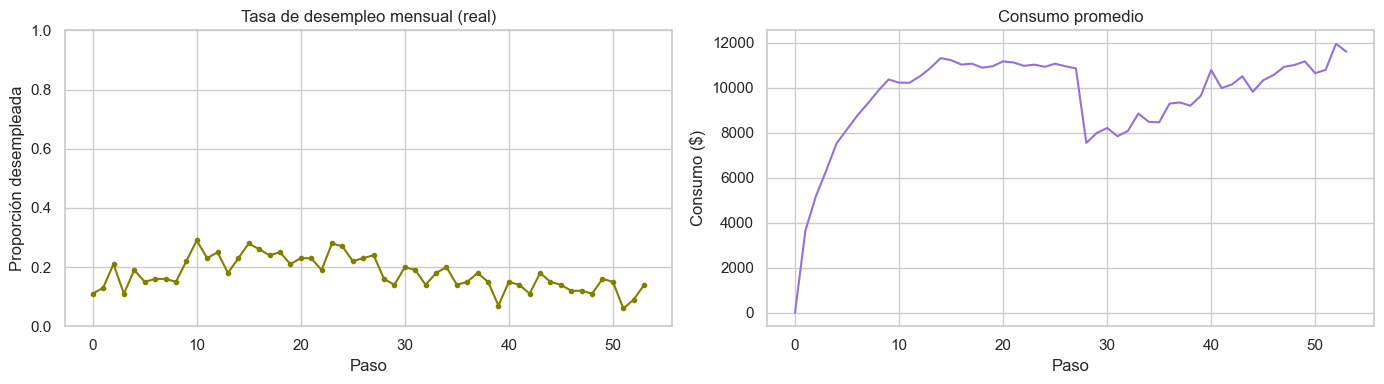

Desempleo mensual: min=0.06  max=0.29  promedio=0.18


In [8]:
# Tasa de desempleo real, a partir de la acción decodificada (no del income como proxy)
work_rate = []
for t in range(T):
    acts = log['actions'][t]
    worked = [1 if 'SimpleLabor' in acts[str(i)] else 0 for i in range(n_agents)]
    work_rate.append(np.mean(worked))
unemployment_rate = [1 - w for w in work_rate]

# Consumo promedio
consumption = np.array([[log['states'][t][str(i)].get('consumption', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T)])
mean_consumption = consumption.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(unemployment_rate, color='olive', marker='o', markersize=3)
axes[0].set_ylim(0, 1)
axes[0].set_title('Tasa de desempleo mensual (real)')
axes[0].set_xlabel('Paso')
axes[0].set_ylabel('Proporción desempleada')

axes[1].plot(mean_consumption, color='mediumpurple')
axes[1].set_title('Consumo promedio')
axes[1].set_xlabel('Paso')
axes[1].set_ylabel('Consumo ($)')

plt.tight_layout()
plt.show()

print(f'Desempleo mensual: min={min(unemployment_rate):.2f}  max={max(unemployment_rate):.2f}  promedio={np.mean(unemployment_rate):.2f}')

## 8. Impuestos y redistribución

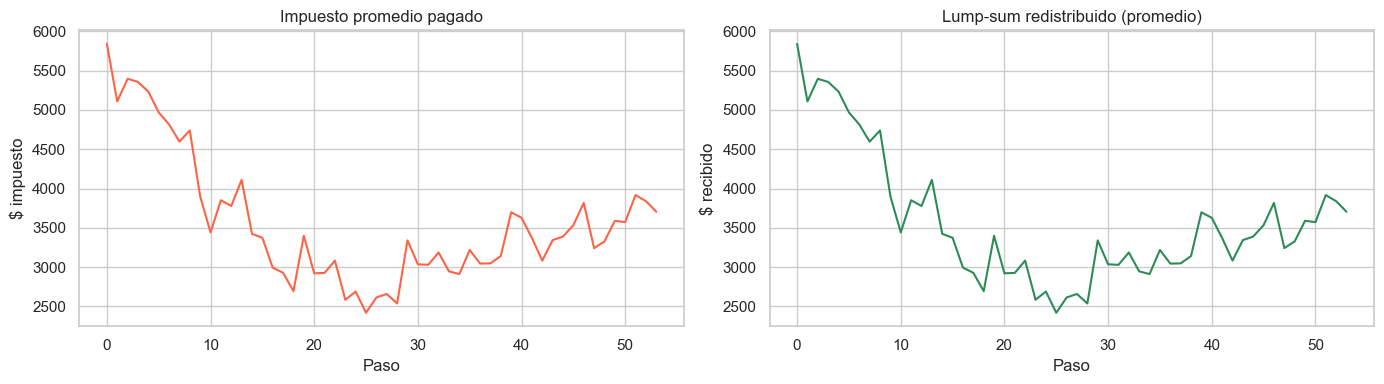

In [9]:
# La clave del componente de impuestos es 'PeriodicTax': una lista (por mes) de dicts
# {'schedule':..., 'cutoffs':..., '<agent_idx>': {'income','tax_paid','marginal_rate','effective_rate','lump_sum'}}
tax_log = log.get('PeriodicTax')

if tax_log:
    tax_paid = np.array([[tax_log[t][str(i)]['tax_paid'] for i in range(n_agents)] for t in range(T)])
    lump_sum = np.array([[tax_log[t][str(i)]['lump_sum'] for i in range(n_agents)] for t in range(T)])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(tax_paid.mean(axis=1), color='tomato')
    axes[0].set_title('Impuesto promedio pagado')
    axes[0].set_xlabel('Paso')
    axes[0].set_ylabel('$ impuesto')

    axes[1].plot(lump_sum.mean(axis=1), color='seagreen')
    axes[1].set_title('Lump-sum redistribuido (promedio)')
    axes[1].set_xlabel('Paso')
    axes[1].set_ylabel('$ recibido')

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron datos de impuestos en el dense_log.')
    print('Claves disponibles:', [k for k in log.keys() if 'Tax' in k or 'tax' in k])

## 9. Resumen estadístico

In [10]:
summary = pd.DataFrame({
    'Riqueza media':       wealth.mean(axis=1),
    'Riqueza mediana':     np.median(wealth, axis=1),
    'Riqueza std':         wealth.std(axis=1),
    'Ingreso medio':       income.mean(axis=1),
    'Consumo medio':       mean_consumption,
    'Gini riqueza':        gini_wealth,
    'Gini ingreso':        gini_income,
})

print(f'=== Estadísticas al INICIO (paso 0) ===')
print(summary.iloc[0].to_string())
print(f'\n=== Estadísticas al ÚLTIMO PASO DISPONIBLE (paso {T-1} de {T}) ===')
print(summary.iloc[-1].to_string())

=== Estadísticas al INICIO (paso 0) ===
Riqueza media      0.0
Riqueza mediana    0.0
Riqueza std        0.0
Ingreso medio      0.0
Consumo medio      0.0
Gini riqueza       1.0
Gini ingreso       1.0

=== Estadísticas al ÚLTIMO PASO DISPONIBLE (paso 53 de 54) ===
Riqueza media      202007.592205
Riqueza mediana    142986.929072
Riqueza std        224602.837349
Ingreso medio       15997.407681
Consumo medio       11598.762363
Gini riqueza            0.556455
Gini ingreso            0.519839


## 10. Inspección puntual de una decisión (debug)

Mira el `actions_{N}.pkl` del checkpoint más reciente para chequear a mano qué decidieron los agentes (útil para lo mismo que veníamos debugueando: truncamiento, parseo de JSON, etc.).

In [11]:
from pprint import pprint

# Directo del dense_log ya cargado, en vez de parsear el nombre del archivo
# (el checkpoint final se llama simplemente 'dense_log.pkl', sin número de paso).
print(f'Acciones del último mes disponible (paso {T}):')
pprint(log['actions'][-1])

Acciones del último mes disponible (paso 54):
{'0': {'SimpleConsumption': 13, 'SimpleLabor': 1},
 '1': {'SimpleConsumption': 13},
 '10': {'SimpleConsumption': 18, 'SimpleLabor': 1},
 '11': {'SimpleConsumption': 3, 'SimpleLabor': 1},
 '12': {'SimpleConsumption': 16, 'SimpleLabor': 1},
 '13': {'SimpleConsumption': 19, 'SimpleLabor': 1},
 '14': {'SimpleConsumption': 15, 'SimpleLabor': 1},
 '15': {'SimpleConsumption': 15},
 '16': {'SimpleConsumption': 14},
 '17': {'SimpleConsumption': 12, 'SimpleLabor': 1},
 '18': {'SimpleConsumption': 19, 'SimpleLabor': 1},
 '19': {'SimpleConsumption': 15},
 '2': {'SimpleConsumption': 18, 'SimpleLabor': 1},
 '20': {'SimpleConsumption': 10, 'SimpleLabor': 1},
 '21': {'SimpleConsumption': 12, 'SimpleLabor': 1},
 '22': {'SimpleConsumption': 6, 'SimpleLabor': 1},
 '23': {'SimpleConsumption': 16, 'SimpleLabor': 1},
 '24': {'SimpleConsumption': 13, 'SimpleLabor': 1},
 '25': {'SimpleConsumption': 17},
 '26': {'SimpleConsumption': 14},
 '27': {'SimpleConsumption'